  Animal Type   Animal Name  Speed  Weight Continent    Country  Lifespan  \
0      Insect  WalkingStick      8     349    Africa  Australia        93   
1        Bird      Hornbill     32     381    Africa     Brazil         2   
2        Bird      Hornbill     93     201    Europe    Germany        32   
3        Bird        Canary     85      21    Europe      Egypt        65   
4      Mammal         Lemur     40      80    Africa     Brazil        11   

  Migration Reproduction Threat Level  
0        No         Live         High  
1       Yes         Eggs       Medium  
2       Yes         Live         High  
3        No         Eggs     Critical  
4       Yes         Live          Low  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     200 non-null    int64
 1   Weight    200 non-null    int64
 2   Lifespan  200 non-null    int64
dtypes: 

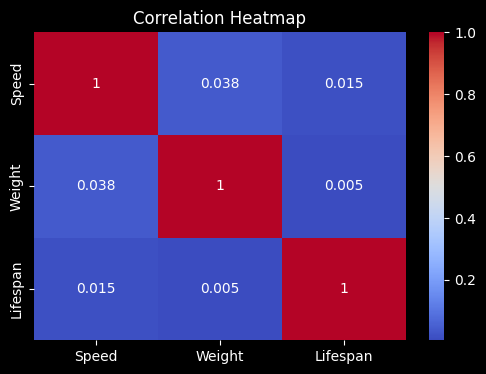

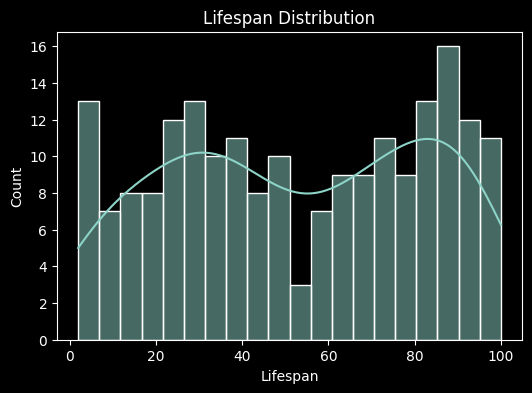

Intercept: 55.769193118983964
Coefficients: [-0.04059099 -0.00321137]
Linear R2: -0.030494006008734864
Polynomial R2: -0.08828935447502761


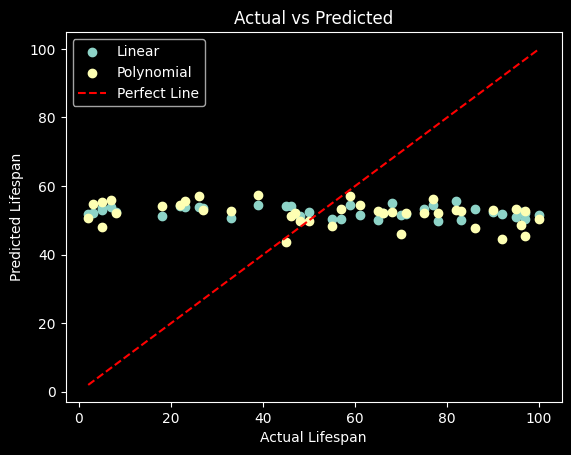

Models Saved Successfully ✅


In [53]:
# ==============================
# 📌 IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# ==============================
# 📌 LOAD DATASET
# ==============================
df = pd.read_csv("animal_species_200_rows.csv")

print(df.head())

# ==============================
# 📌 DATA CLEANING
# ==============================
df = df[['Speed', 'Weight', 'Lifespan']]
df = df.dropna()

print(df.info())

# ==============================
# 📌 CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 📌 LIFESPAN DISTRIBUTION
# ==============================
plt.figure(figsize=(6,4))
sns.histplot(df['Lifespan'], bins=20, kde=True)
plt.title("Lifespan Distribution")
plt.show()

# ==============================
# 📌 SPLIT DATA
# ==============================
X = df[['Speed', 'Weight']]
y = df['Lifespan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# 📌 LINEAR REGRESSION MODEL
# ==============================
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Intercept:", linear_model.intercept_)
print("Coefficients:", linear_model.coef_)

# Predictions
y_pred_linear = linear_model.predict(X_test)

# ==============================
# 📌 POLYNOMIAL MODEL
# ==============================
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

# ==============================
# 📌 R2 SCORES
# ==============================
r2_linear = r2_score(y_test, y_pred_linear)
r2_poly = r2_score(y_test, y_pred_poly)

print("Linear R2:", r2_linear)
print("Polynomial R2:", r2_poly)

# ==============================
# 📌 ACTUAL VS PREDICTED PLOT
# ==============================
plt.scatter(y_test, y_pred_linear, label="Linear")
plt.scatter(y_test, y_pred_poly, label="Polynomial")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Line")

plt.xlabel("Actual Lifespan")
plt.ylabel("Predicted Lifespan")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# ==============================
# 📌 SAVE MODELS
# ==============================
pickle.dump(linear_model, open("linear_model.pkl", "wb"))
pickle.dump(poly_model, open("poly_model.pkl", "wb"))
pickle.dump(poly, open("poly_converter.pkl", "wb"))

print("Models Saved Successfully ✅")